In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from jqdatasdk import *
from calc_fac import calc
from extract_fac import extract_fac
import plotly as py
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
import cufflinks
from plotly.subplots import make_subplots
from concurrent.futures import ProcessPoolExecutor
from backtrade import back_trade
cufflinks.go_offline(connected=True)
init_notebook_mode(connected=True)
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from  matplotlib.figure import Figure

d:\anaconda\envs\Yassin\lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.0.2) or chardet (5.0.0)/charset_normalizer (2.1.1) doesn't match a supported version!
  warnings.warn(


window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

window.PlotlyConfig = {MathJaxConfig: 'local'};
 if (window.MathJax && window.MathJax.Hub && window.MathJax.Hub.Config) {window.MathJax.Hub.Config({SVG: {font: "STIX-Web"}});}
 if (typeof require !== 'undefined') {
 require.undef("plotly");
 requirejs.config({
 paths: {
 'plotly': ['https://cdn.plot.ly/plotly-2.12.1.min']
 }
 });
 require(['plotly'], function(Plotly) {
 window._Plotly = Plotly;
 });
 }

这里只回测了 2022 年 到 2023-04 的数据

因为分钟级别的数据太大了，下载也慢，算的也慢,我看研报里面给了一部分了，前面的部分就默认他是对的了，来看看后续的表现怎么样

研报 pdf 在附件

另外分钟级别的数据建议也不要找我要，我确实也不全…… 上传也太慢了。

0. 整个因子计算的过程都依赖于 “涨潮时刻”， “顶峰时刻”， “退潮时刻”， 且仅依赖于这三个时点的信息，所以就提前算一下

这里简单说下研报对于“潮”的定义：

· 首先我们将成交量聚合， $t$ 分钟的 “邻域成交量” 为 $[t-4,t+4]$ 的成交量的和

· 其次，假设邻域成交量发生在第 $t$ 分钟，那么将 $t$ 称为 “顶峰时刻”

· 在第 [5,t-1] 分钟内，邻域成交量的最低点发生在第 $m$ 分钟，那么我们称这一点为“涨潮时刻”，从涨潮时刻到顶峰时刻的过程叫做 “涨潮”

· 在第 [t+1, 233] 分钟内，邻域成交量的最低点发生在第 $n$ 分钟，那么我们称这一点为 “退潮时刻”， 从顶峰时刻到退潮时刻的过程叫做 “退潮”

下面先按照定义，求出三个时刻，及三个时刻对应的 “邻域成交量” 以及收盘价

In [2]:
def login():
    auth('Name', 'Password')
    print(get_query_count())

In [3]:
login()
# calc("2022-01-04")

begin_date = "2020-01-01"
end_date= "2023-04-30"

auth success 
{'total': 500000, 'spare': 473787}


In [4]:
# #这个计算略微有点慢，加速一下。
# trade_cal = get_trade_days(start_date=begin_date, end_date=end_date)
# trade_cal = [_.strftime("%Y-%m-%d") for _ in trade_cal]

# # 用多进程加速
# with ProcessPoolExecutor(max_workers=8) as pool:
#     pool.map(calc, trade_cal)

In [5]:
df = extract_fac("2022-01-01", "2023-04-30")
df.to_pickle("fac2.pkl")
df.head(10)

,code,min_pos_1,max_pos,min_pos_2,min_pos_1_vol,max_pos_vol,min_pos_2_vol,min_pos_1_close,max_pos_close,min_pos_2_close,date
0,000001.XSHE,723128,723129,723222,13326374.0,13485297.0,1020280.0,15.60,15.57,15.67,2022-01-04
1,000002.XSHE,301212,301232,301376,4933940.0,26991456.0,2356217.0,18.47,18.98,19.38,2022-01-04
2,000004.XSHE,330005,330043,330166,221700.0,537859.0,34700.0,19.63,19.96,20.08,2022-01-04
3,000005.XSHE,229712,229722,229855,186400.0,2022300.0,42500.0,2.30,2.32,2.32,2022-01-04
4,000006.XSHE,515296,515312,515387,437018.0,1600142.0,74738.0,4.33,4.36,4.40,2022-01-04
5,000007.XSHE,217928,217929,218103,833400.0,797500.0,37100.0,6.16,6.14,6.19,2022-01-04
6,000008.XSHE,264253,264259,264345,11816103.0,20766797.0,1586700.0,2.92,2.96,2.95,2022-01-04
7,000009.XSHE,825855,825878,826033,6366241.0,13074372.0,699759.0,14.22,13.93,13.95,2022-01-04
8,000010.XSHE,512407,512417,512499,522500.0,923900.0,26500.0,3.78,3.80,3.82,2022-01-04
9,000011.XSHE,708025,708033,708126,268391.0,518096.0,78660.0,11.01,11.05,11.12,2022-01-04


In [9]:
def show(df, Name, Type = 0):
    '''
        Type = 0 时 用 plotly 绘图
        Type = 1 时 用 matplotlib 绘图
    '''
    if Type == 0:
        df["date"] = pd.to_datetime(df["date"])
        trace0 = go.Scatter(x = df["date"], y = df["ret_0"], name = "group_0")
        trace1 = go.Scatter(x = df["date"], y = df["ret_1"], name = "group_1")
        trace2 = go.Scatter(x = df["date"], y = df["ret_2"], name = "group_2")
        trace3 = go.Scatter(x = df["date"], y = df["ret_3"], name = "group_3")
        trace4 = go.Scatter(x = df["date"], y = df["ret_4"], name = "group_4")
        trace5 = go.Scatter(x = df["date"], y = df["ret_5"], name = "group_5")
        trace6 = go.Scatter(x = df["date"], y = df["ret_6"], name = "group_6")
        trace7 = go.Scatter(x = df["date"], y = df["ret_7"], name = "group_7")
        trace8 = go.Scatter(x = df["date"], y = df["ret_8"], name = "group_8")
        trace9 = go.Scatter(x = df["date"], y = df["ret_9"], name = "group_9")

        fig = make_subplots(specs=[[{'secondary_y': True}]])
        
        data = [trace0, trace1, trace2, trace3, trace4, trace5, trace6, trace7, trace8, trace9]
        fig.add_traces(data)

        fig.add_trace(
            go.Scatter(x=df["date"], y=df["ret_0"] / df["ret_9"], name="多空差异"),
            secondary_y=True,
        )
        
        fig.update_layout(
            title = Name, 
            xaxis_title = "Date",
            yaxis_title = "Return",
        )

        fig.show()
    else:
        fig = Figure(figsize=(25, 9), dpi=100)
        plt.subplot(2,1,1)
        for i in range(0, 10):
            plt.plot(df["date"], df["ret_{}".format(i)], label = "group_{}".format(i))
        plt.legend()
        plt.title(Name)
        plt.subplot(2,1,2)
        plt.plot(df["date"], df["ret_0"] / df["ret_9"], label = "call_put_diff")
        plt.legend()
        plt.show()

首先来做一下第一个因子， 只考虑起点到终点的收益率变化速率

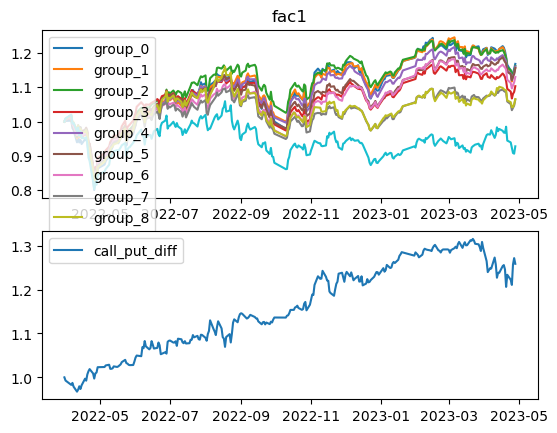

In [10]:
df["fac1_temp"] = (df["min_pos_2_close"] - df["min_pos_1_close"]) / df["min_pos_1_close"] / (df["min_pos_2"] - df["min_pos_1"])
df["fac1"] = df.groupby("code", as_index = False)["fac1_temp"].apply(lambda x:x.rolling(20).mean())

fac1_df = back_trade(df, "fac1")
show(fac1_df, "fac1", Type = 1)

多空收益还可以，但是第 0 组的表现并没有显著好于其他组，可能不同组的收益并不是单调的

接下来我们考察“涨潮”与“退潮”所蕴含的能量大小，以“顶峰时刻”为界，将“潮汐”拆分成2 个“半潮汐”，进而构造“强势半潮汐”因子和“弱势半潮汐”因子，具体过程如下：


1. 如上述定义，“涨潮时刻”的“邻域成交量”为Vm，“退潮时刻” 的 “邻域成交量” 为Vn。

2. 如果Vm < Vn，则认为“涨潮”过程的起点更低，因此推动涨潮的力量需要更强大，所以我们定义“涨潮”是“强势半潮汐”，进而“退潮”就是“弱势半潮汐”。

3. 反之如果Vm>Vn，则认为“退潮”过程的终点更低，因此推动退潮的力量需要更强大，所以我们定义“退潮”是“强势半潮汐”，进而“涨潮” 就是“弱势半潮汐”。

强势半潮汐因子构建

1. 与计算“全潮汐”因子的方法类似，我们先计算“强势半潮汐” 过程的起止收盘价的涨跌幅。

2.然后将涨跌幅除以“强势半潮汐”持续的分钟数，即可得到每日推动力量更大的一部分价格变化的速率。并将此作为投资者买卖意愿相对更强烈的时间段投资者交易热情的代理变量。

3. 我们计算最近20 个交易日的价格变动速率的**平均值** ，记为“强势半潮汐”因子。

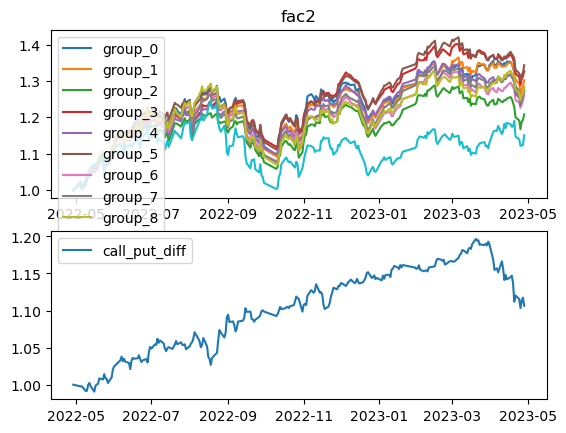

In [11]:
#  涨潮变化率和退潮变化率
df["up_rate"] = (df["max_pos_close"] - df["min_pos_1_close"]) / df["min_pos_1_close"] / (df["max_pos"] - df["min_pos_1"])
df["down_rate"] = (df["min_pos_2_close"] - df["max_pos_close"]) / df["max_pos_close"] / (df["min_pos_2"] - df["max_pos"])

df["strength"] = df["min_pos_1_vol"] > df["min_pos_2_vol"]
df["strength"] = df["strength"].apply(lambda x: 1 if x else -1)


df["fac2_temp"] = df.apply(lambda x: np.where(x["strength"] == 1, x["up_rate"], x["down_rate"]), axis = 1)
df["fac2"] = df.groupby("code", as_index = False)["fac2_temp"].apply(lambda x:x.rolling(20).mean())

fac2_df = back_trade(df, "fac2")
show(fac2_df, "fac2", Type = 1)

多空收益还可以，但是最低的一组表现的不好，看起来 2 3 4 组表现的更好一些，属于下跌后的反转

最高的一组表现最差，大幅的拉升不可持续

计算“弱势半潮汐”过程中 的价格变动速率 。


具体过程如下

1. 与计算“强势半潮汐”因子的方法类似 我们先计算“弱势半潮汐”过程的起止收盘价的涨跌幅 。

2. 然后将涨跌幅除以“弱势半潮汐”持续的分钟数 即可得到每日推动力量相对较小的一段时间内 的 价格变化的速率 。 作为投资者买卖意愿 相对较弱 的时段投资者交易热情的代理变量。


3. 接下来我们通过两种不同的方式刻画因子，其一是我们计算最近20 个交易日弱势半潮汐内的 价格变动速率的平均值 ，其二是 我们计算最近 20 个交易日的 价格变动速率的标准差 ，并分别记为 “激进弱势半潮汐”因子 和 “稳定弱势半潮汐”因子 。

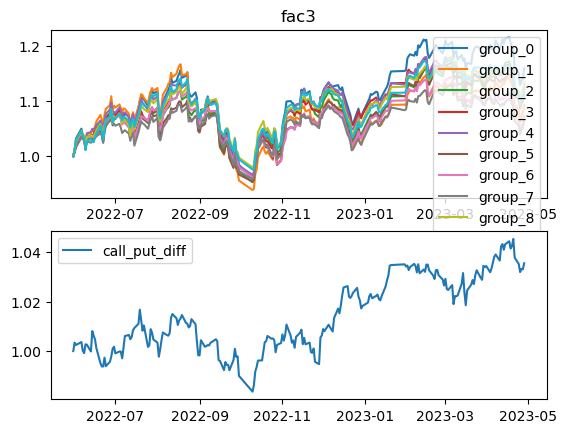

In [12]:
df["fac3_temp"] = df.apply(lambda x: np.where(x["strength"] == 0, x["up_rate"], x["down_rate"]), axis = 1)
df["fac3"] = df.groupby("code", as_index = False)["fac3_temp"].apply(lambda x: x.rolling(20).mean())
df["fac4"] = df.groupby("code", as_index = False)["fac3_temp"].apply(lambda x: x.rolling(20).std())

fac3_df = back_trade(df, "fac3")
show(fac3_df, "fac3", Type = 1)

很一般的因子，多空收益不明显。

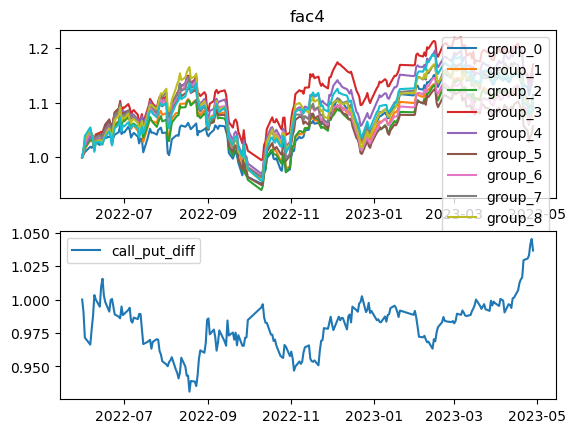

In [13]:
fac4_df = back_trade(df, "fac4")
show(fac4_df, "fac4", Type = 1)

可以舍弃的因子

最后将表现较为稳定的强势半潮汐因子和弱势稳定半潮汐因子进行等权合并，组成最后的 $fin_{fac}$

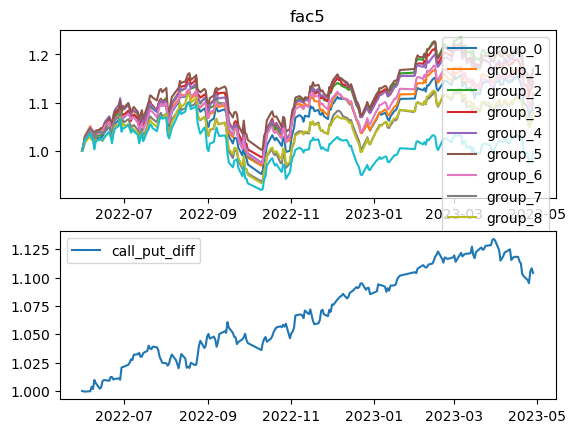

In [14]:
def z_score(g):
    return (g - g.mean()) / g.std()

df["fac2_z"] = df.groupby("code")["fac2"].apply(z_score)
df["fac3_z"] = df.groupby("code")["fac3"].apply(z_score)

df["fac5"] = df["fac2_z"] + df["fac3_z"]
fac5_df = back_trade(df, "fac5")
show(fac5_df, "fac5", Type = 1)

多空收益几乎拉成一条直线，分组也比较显著了，前 7 组也是可以显著跑过后 3 组的